In [89]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
def leggere_file():
    df_sales = pd.read_csv("SALES.csv")
    df_company = pd.read_csv("COMPANY_LOOKUP.csv")
    df_items = pd.read_csv("ITEM_LOOKUP.csv")
    df_lines = pd.read_csv("ITEM_BUSINESS_LINE_LOOKUP.csv")
    df_costumers = pd.read_csv("CUSTOMER_LOOKUP.csv")
    df_area = pd.read_csv("AREA_MANAGER_LOOKUP.csv")

    return df_sales, df_company, df_items, df_lines, df_customers, df_area

In [93]:
def rimuovere_duplicati(df):
    return df.drop_duplicates()

In [95]:
def merge_data(df_sales, df_company, df_items, df_lines, df_customers, df_area):
    df = df_sales.merge(df_company, on="ID_COMPANY", how="left")
    df = df.merge(df_items, on="IDS_ITEM", how="left")
    df = df.merge(df_lines, on="ID_BUSINESS_LINE", how="left")
    df = df.merge(df_customers, on="IDS_CUSTOMER", how="left")
    df = df.merge(df_area, on="ID_AREA_MANAGER", how="left")
    return df

In [97]:
def conversione_date_invoice(df):
    min_date = pd.Timestamp("1900-01-01")
    max_date = pd.Timestamp("today")

    df["ID_INVOICE_DATE"] = pd.to_datetime(
        df["ID_INVOICE_DATE"],
        format="%Y%m%d",
        errors="coerce"
    )

    mask = (df["ID_INVOICE_DATE"] < min_date) | (df["ID_INVOICE_DATE"] > max_date)

    df.loc[mask, "ID_INVOICE_DATE"] = pd.NaT

    print("Valori NaN in ID_INVOICE_DATE: ", df["ID_INVOICE_DATE"].isna().sum())

    media_data = df["ID_INVOICE_DATE"].mean()
    df["ID_INVOICE_DATE"] = df["ID_INVOICE_DATE"].fillna(media_data)

    return df

In [99]:
def conversione_date_order(df):
    min_date = pd.Timestamp("1900-01-01")
    max_date = pd.Timestamp("today")

    df["ID_ORDER_DATE"] = pd.to_datetime(
        df["ID_ORDER_DATE"],
        format="%Y%m%d",
        errors="coerce"
    )

    mask = (df["ID_ORDER_DATE"] < min_date) | (df["ID_ORDER_DATE"] > max_date)

    df.loc[mask, "ID_ORDER_DATE"] = pd.NaT

    print("Valori NaN in ID_ORDER_DATE: ", df["ID_ORDER_DATE"].isna().sum())

    media_data = df["ID_ORDER_DATE"].mean()
    df["ID_ORDER_DATE"] = df["ID_ORDER_DATE"].fillna(media_data)

    return df

In [101]:
def creazione_copia(df):
    return df.copy()

In [103]:
def encoding_colonne(df):
    le = LabelEncoder()

    df["ID_COMPANY"] = le.fit_transform(df["ID_COMPANY"])
    df["IDS_ITEM"] = le.fit_transform(df["IDS_ITEM"])
    df["ID_BUSINESS_LINE"] = le.fit_transform(df["ID_BUSINESS_LINE"])
    df["IDS_CUSTOMER"] = le.fit_transform(df["IDS_CUSTOMER"])
    df["ID_AREA_MANAGER"] = le.fit_transform(df["ID_AREA_MANAGER"])
    df["ID_COUNTRY"] = le.fit_transform(df["ID_COUNTRY"])

    return df

In [105]:
def drop_colonne(df):
    return df.drop(columns=[
        "DESC_COMPANY",
        "DESC_ITEM",
        "DESC_BUSINESS_LINE",
        "DESC_CUSTOMER",
        "DESC_AREA_MANAGER"
    ])

In [107]:
def calcolo_matrice_corr(df):
    return df.corr()

In [109]:
def plot_heatmap(matrix):
    plt.figure()
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.show()

Valori NaN in ID_INVOICE_DATE:  14
Valori NaN in ID_ORDER_DATE:  0


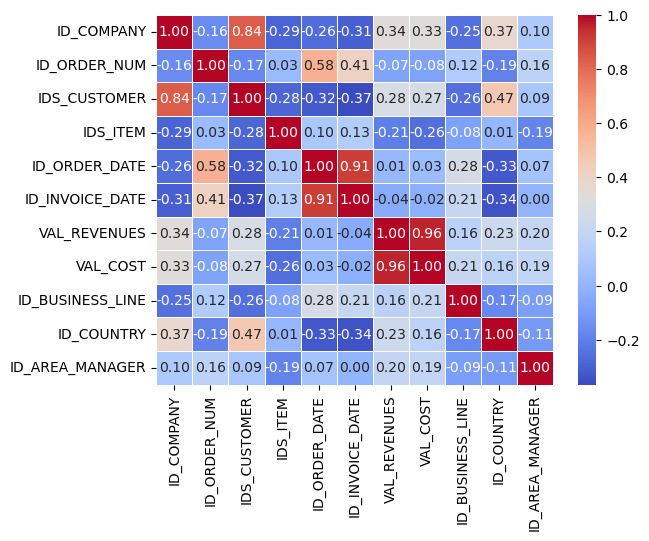

In [111]:
def main():
    df_sales, df_company, df_items, df_lines, df_customers, df_area = leggere_file()

    df_company = rimuovere_duplicati(df_company)
    df_items = rimuovere_duplicati(df_items)
    df_lines = rimuovere_duplicati(df_lines)
    df_customers = rimuovere_duplicati(df_customers)
    df_area = rimuovere_duplicati(df_area)

    df = merge_data(df_sales, df_company, df_items, df_lines, df_customers, df_area)

    df = conversione_date_invoice(df)
    df = conversione_date_order(df)

    df_ml = creazione_copia(df)

    df_ml = encoding_colonne(df_ml)

    df_ml = drop_colonne(df_ml)

    matrix = calcolo_matrice_corr(df_ml)

    plot_heatmap(matrix)


if __name__ == "__main__":
    main()

In [113]:
df.isnull().sum().sum()

0